# Modeling Notebook for Credit Default Data



In [15]:
import os
import re
import tempfile
import warnings
from pathlib import Path
from credit_decisioning import LOW_RISK_CUTOFF, HIGH_RISK_CUTOFF
FAIRNESS_SUMMARY_PATH = Path('fairness_summary.json')

os.environ.setdefault('MPLCONFIGDIR', tempfile.mkdtemp(prefix='mpl-config-'))
os.environ.setdefault('XDG_CACHE_HOME', tempfile.mkdtemp(prefix='xdg-cache-'))
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

try:
    import xgboost as xgb
except ImportError as exc:
    raise ImportError('xgboost is required for this notebook. Install it in the project virtual environment before running.') from exc

try:
    import shap
except ImportError as exc:
    raise ImportError('shap is required for this notebook. Install it in the project virtual environment before running.') from exc

try:
    import imblearn
    from imblearn.over_sampling import SMOTE
except ImportError as exc:
    raise ImportError('imblearn is required for the optimization section. Install it in the project virtual environment before running.') from exc

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
TARGET = 'Credit Default'
DATA_PATH = Path('data/credit-default-data.csv')

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('xgboost', xgb.__version__)
print('shap', shap.__version__)
print('imblearn', imblearn.__version__)


pandas 2.2.2
numpy 1.26.4
xgboost 2.1.4
shap 0.49.1
imblearn 0.12.3


## Split the Raw Data First

The raw dataset is split before any train-fitted preprocessing. This keeps imputation statistics and categorical schemas leakage-safe.


In [2]:
raw_df = pd.read_csv(DATA_PATH)
X_raw = raw_df.drop(columns=[TARGET]).copy()
y = raw_df[TARGET].copy()

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [X_train_raw.shape[0], X_val_raw.shape[0], X_test_raw.shape[0]],
    'default_cases': [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    'non_default_cases': [int((y_train == 0).sum()), int((y_val == 0).sum()), int((y_test == 0).sum())],
})

display(split_summary)
print(f'Training samples: {len(y_train)} | Validation samples: {len(y_val)} | Test samples: {len(y_test)}')
print(f'Default cases in validation: {int(y_val.sum())} | Non-default in validation: {int((y_val == 0).sum())}')


,split,rows,default_cases,non_default_cases
0,train,5250,1479,3771
1,validation,1125,317,808
2,test,1125,317,808


Training samples: 5250 | Validation samples: 1125 | Test samples: 1125
Default cases in validation: 317 | Non-default in validation: 808


## Leakage-Safe Preprocessing

Deterministic cleaning is applied row-wise, then train-only artifacts are fit on `X_train_raw`, and finally reused to transform validation and test.


In [3]:
def job_tenure_to_years(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == '< 1 year':
        return 0.5
    if value == '10+ years':
        return 10.0
    match = re.search(r'(\d+)', value)
    return float(match.group(1)) if match else np.nan

def apply_deterministic_cleaning(df):
    working_df = df.copy()

    working_df['income_missing_flag'] = working_df['Annual Income'].isna().astype(int)
    working_df['credit_score_missing_flag'] = working_df['Credit Score'].isna().astype(int)
    working_df['job_tenure_missing_flag'] = working_df['Years in current job'].isna().astype(int)
    working_df['delinquency_missing_flag'] = working_df['Months since last delinquent'].isna().astype(int)

    working_df['loan_amount_placeholder_flag'] = working_df['Current Loan Amount'].eq(99999999).astype(int)
    working_df['Home Ownership'] = working_df['Home Ownership'].replace({'Have Mortgage': 'Home Mortgage'})
    working_df['Current Loan Amount'] = working_df['Current Loan Amount'].mask(working_df['loan_amount_placeholder_flag'].eq(1))
    working_df['Credit Score'] = working_df['Credit Score'].where(working_df['Credit Score'] <= 850, working_df['Credit Score'] / 10)
    working_df['job_tenure_years'] = working_df['Years in current job'].apply(job_tenure_to_years)

    working_df = working_df.drop(columns=['Id', 'Years in current job'])
    return working_df

def fit_train_preprocessor(train_raw_df):
    train_clean = apply_deterministic_cleaning(train_raw_df)

    impute_cols = [
        'Annual Income',
        'Credit Score',
        'Current Loan Amount',
        'job_tenure_years',
        'Months since last delinquent',
        'Bankruptcies',
    ]
    imputation_medians = {col: float(train_clean[col].median()) for col in impute_cols}

    train_working = train_clean.copy()
    for col, median_value in imputation_medians.items():
        train_working[col] = train_working[col].fillna(median_value)

    train_working['monthly_dti'] = train_working['Monthly Debt'] / (train_working['Annual Income'] / 12)
    train_working['credit_utilization_proxy'] = train_working['Current Credit Balance'] / train_working['Maximum Open Credit'].replace(0, np.nan)
    train_working['loan_to_income_ratio'] = train_working['Current Loan Amount'] / train_working['Annual Income']
    credit_utilization_median = float(train_working['credit_utilization_proxy'].median())
    train_working['credit_utilization_proxy'] = train_working['credit_utilization_proxy'].fillna(credit_utilization_median)

    base_numeric_cols = [
        'Annual Income',
        'Tax Liens',
        'Number of Open Accounts',
        'Years of Credit History',
        'Maximum Open Credit',
        'Number of Credit Problems',
        'Months since last delinquent',
        'Bankruptcies',
        'Current Loan Amount',
        'Current Credit Balance',
        'Monthly Debt',
        'Credit Score',
        'job_tenure_years',
    ]
    engineered_numeric_cols = [
        'monthly_dti',
        'credit_utilization_proxy',
        'loan_to_income_ratio',
    ]
    flag_cols = [
        'loan_amount_placeholder_flag',
        'income_missing_flag',
        'credit_score_missing_flag',
        'job_tenure_missing_flag',
        'delinquency_missing_flag',
    ]
    categorical_cols = ['Home Ownership', 'Purpose', 'Term']
    feature_cols = base_numeric_cols + engineered_numeric_cols + flag_cols + categorical_cols

    prepared_train_df = train_working[feature_cols].copy()
    X_train = pd.get_dummies(
        prepared_train_df,
        columns=categorical_cols,
        drop_first=False,
        dtype=int,
    ).sort_index(axis=1)

    artifacts = {
        'imputation_medians': imputation_medians,
        'credit_utilization_median': credit_utilization_median,
        'base_numeric_cols': base_numeric_cols,
        'engineered_numeric_cols': engineered_numeric_cols,
        'flag_cols': flag_cols,
        'categorical_cols': categorical_cols,
        'feature_cols': feature_cols,
        'encoded_columns': X_train.columns.tolist(),
    }
    return artifacts, prepared_train_df, X_train

def transform_split(raw_df, preprocessor_artifacts):
    working_df = apply_deterministic_cleaning(raw_df)

    for col, median_value in preprocessor_artifacts['imputation_medians'].items():
        working_df[col] = working_df[col].fillna(median_value)

    working_df['monthly_dti'] = working_df['Monthly Debt'] / (working_df['Annual Income'] / 12)
    working_df['credit_utilization_proxy'] = working_df['Current Credit Balance'] / working_df['Maximum Open Credit'].replace(0, np.nan)
    working_df['loan_to_income_ratio'] = working_df['Current Loan Amount'] / working_df['Annual Income']
    working_df['credit_utilization_proxy'] = working_df['credit_utilization_proxy'].fillna(preprocessor_artifacts['credit_utilization_median'])

    prepared_df = working_df[preprocessor_artifacts['feature_cols']].copy()
    encoded_df = pd.get_dummies(
        prepared_df,
        columns=preprocessor_artifacts['categorical_cols'],
        drop_first=False,
        dtype=int,
    ).sort_index(axis=1)
    encoded_df = encoded_df.reindex(columns=preprocessor_artifacts['encoded_columns'], fill_value=0)
    return prepared_df, encoded_df

preprocessor_artifacts, prepared_train_df, X_train = fit_train_preprocessor(X_train_raw)
prepared_val_df, X_val = transform_split(X_val_raw, preprocessor_artifacts)
prepared_test_df, X_test = transform_split(X_test_raw, preprocessor_artifacts)

prep_summary = pd.DataFrame({
    'object_name': ['prepared_train_df', 'prepared_val_df', 'prepared_test_df', 'X_train', 'X_val', 'X_test'],
    'rows': [prepared_train_df.shape[0], prepared_val_df.shape[0], prepared_test_df.shape[0], X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    'columns': [prepared_train_df.shape[1], prepared_val_df.shape[1], prepared_test_df.shape[1], X_train.shape[1], X_val.shape[1], X_test.shape[1]],
})

display(prep_summary)
print('Train-only imputation medians learned for:', list(preprocessor_artifacts['imputation_medians'].keys()))
print('Encoded train feature count:', len(preprocessor_artifacts['encoded_columns']))


,object_name,rows,columns
0,prepared_train_df,5250,24
1,prepared_val_df,1125,24
2,prepared_test_df,1125,24
3,X_train,5250,41
4,X_val,1125,41
5,X_test,1125,41


Train-only imputation medians learned for: ['Annual Income', 'Credit Score', 'Current Loan Amount', 'job_tenure_years', 'Months since last delinquent', 'Bankruptcies']
Encoded train feature count: 41


## Train-Only Feature Correlation With Target

Correlation is computed on `X_train` only.


,feature,correlation_with_target,abs_correlation
0,loan_amount_placeholder_flag,-0.228,0.228
1,Term_Long Term,0.184,0.184
2,Term_Short Term,-0.184,0.184
3,Credit Score,-0.162,0.162
4,loan_to_income_ratio,0.146,0.146
5,monthly_dti,0.113,0.113
6,Current Loan Amount,0.091,0.091
7,Annual Income,-0.087,0.087
8,credit_utilization_proxy,0.083,0.083
9,income_missing_flag,0.072,0.072


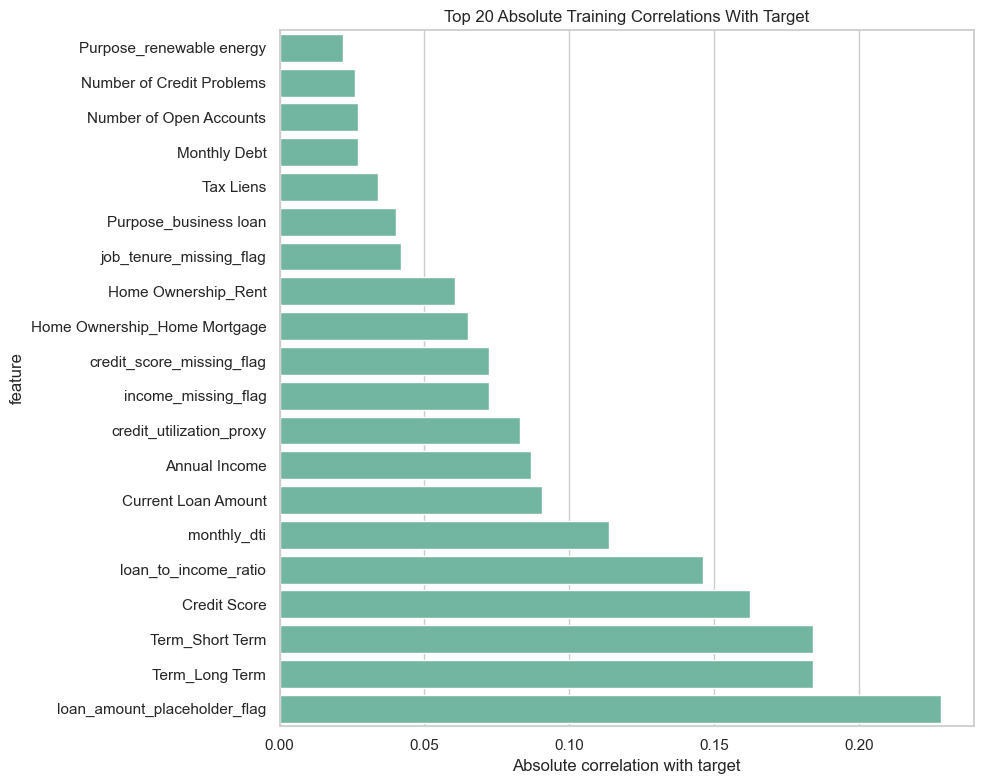

In [4]:
correlation_table = pd.DataFrame({
    'feature': X_train.columns,
    'correlation_with_target': X_train.corrwith(y_train),
})
correlation_table['abs_correlation'] = correlation_table['correlation_with_target'].abs()
correlation_table = correlation_table.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

display(correlation_table)

top_corr_plot = correlation_table.head(20).sort_values('abs_correlation', ascending=True)
plt.figure(figsize=(10, 8))
sns.barplot(data=top_corr_plot, x='abs_correlation', y='feature', color=sns.color_palette('Set2')[0])
plt.title('Top 20 Absolute Training Correlations With Target')
plt.xlabel('Absolute correlation with target')
plt.ylabel('feature')
plt.tight_layout()
plt.show()


## Modeling and Interpretation Helpers

The helper functions below keep the development comparisons validation-only and reserve the test split for the final held-out report.


In [5]:
def make_xgb_classifier(**overrides):
    params = {
        'objective': 'binary:logistic',
        'random_state': RANDOM_STATE,
        'n_jobs': 1,
        'tree_method': 'hist',
        'importance_type': 'gain',
        'eval_metric': 'auc',
    }
    params.update(overrides)
    return xgb.XGBClassifier(**params)

def get_prediction_scores(model, X):
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict_proba(X)[:, 1]

def build_split_result(y_true, y_pred, y_score):
    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_score': y_score,
        'classification_report_df': pd.DataFrame(
            classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        ).T,
        'confusion_matrix': confusion_matrix(y_true, y_pred),
    }

def build_metric_row(model_name, split_name, y_true, y_pred, y_score):
    return {
        'model_name': model_name,
        'split': split_name,
        'samples': len(y_true),
        'roc_auc': roc_auc_score(y_true, y_score),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

def build_results_from_predictions(split_predictions, model_name, model=None, threshold=None):
    split_results = {}
    metric_rows = []
    for split_name, payload in split_predictions.items():
        y_true = payload['y_true']
        y_pred = payload['y_pred']
        y_score = payload['y_score']
        split_results[split_name] = build_split_result(y_true, y_pred, y_score)
        metric_rows.append(build_metric_row(model_name, split_name, y_true, y_pred, y_score))
    results = {
        'model_name': model_name,
        'model': model,
        'split_results': split_results,
        'metrics_table': pd.DataFrame(metric_rows),
    }
    if threshold is not None:
        results['threshold'] = threshold
    return results

def evaluate_binary_classifier(model, X_train, y_train, X_val, y_val, model_name):
    split_predictions = {
        'train': {
            'y_true': y_train,
            'y_pred': model.predict(X_train),
            'y_score': get_prediction_scores(model, X_train),
        },
        'validation': {
            'y_true': y_val,
            'y_pred': model.predict(X_val),
            'y_score': get_prediction_scores(model, X_val),
        },
    }
    return build_results_from_predictions(split_predictions, model_name, model=model)

def evaluate_probability_model_with_threshold(model, X_train, y_train, X_val, y_val, model_name, threshold):
    split_predictions = {}
    for split_name, X_split, y_split in [
        ('train', X_train, y_train),
        ('validation', X_val, y_val),
    ]:
        y_score = model.predict_proba(X_split)[:, 1]
        y_pred = (y_score >= threshold).astype(int)
        split_predictions[split_name] = {
            'y_true': y_split,
            'y_pred': y_pred,
            'y_score': y_score,
        }
    return build_results_from_predictions(split_predictions, model_name, model=model, threshold=threshold)

def evaluate_final_model(model, threshold, X_train, y_train, X_val, y_val, X_test, y_test, model_name):
    split_predictions = {}
    for split_name, X_split, y_split in [
        ('train', X_train, y_train),
        ('validation', X_val, y_val),
        ('test', X_test, y_test),
    ]:
        y_score = get_prediction_scores(model, X_split)
        if threshold is None:
            y_pred = model.predict(X_split)
        else:
            y_pred = (y_score >= threshold).astype(int)
        split_predictions[split_name] = {
            'y_true': y_split,
            'y_pred': y_pred,
            'y_score': y_score,
        }
    return build_results_from_predictions(split_predictions, model_name, model=model, threshold=threshold)

def display_model_evaluation(results, report_split='validation'):
    display(Markdown(f"### {results['model_name']} Metrics"))
    display(results['metrics_table'])
    if report_split in results['split_results']:
        display(Markdown(f"#### {report_split.title()} Classification Report"))
        display(results['split_results'][report_split]['classification_report_df'])

def plot_confusion_matrices(results, splits=('train', 'validation')):
    fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 5))
    if len(splits) == 1:
        axes = [axes]
    for ax, split_name in zip(axes, splits):
        cm = results['split_results'][split_name]['confusion_matrix']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-default', 'Default'])
        disp.plot(ax=ax, colorbar=False)
        ax.set_title(f"{results['model_name']} - {split_name.title()} Confusion Matrix")
    plt.tight_layout()
    plt.show()

def plot_precision_recall_curves(results, splits=('train', 'validation')):
    plt.figure(figsize=(8, 6))
    palette = sns.color_palette('Set2', n_colors=max(2, len(splits)))
    for idx, split_name in enumerate(splits):
        y_true = results['split_results'][split_name]['y_true']
        y_score = results['split_results'][split_name]['y_score']
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        plt.plot(recall, precision, label=split_name.title(), color=palette[idx])
    plt.title(f"{results['model_name']} Precision-Recall Curve")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_top_feature_scores(score_df, score_col, title, top_n=15):
    plot_df = score_df.sort_values(score_col, ascending=False).head(top_n).sort_values(score_col, ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, x=score_col, y='feature', color=sns.color_palette('Set2')[2])
    plt.title(title)
    plt.xlabel(score_col)
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()

def plot_threshold_search(precisions, recalls, thresholds, optimal_idx, title='Threshold Optimization on Validation Split'):
    thresholds = np.asarray(thresholds)
    precisions = np.asarray(precisions)
    recalls = np.asarray(recalls)
    if len(precisions) == len(thresholds) + 1:
        precisions = precisions[:-1]
    if len(recalls) == len(thresholds) + 1:
        recalls = recalls[:-1]
    plt.figure(figsize=(9, 6))
    plt.plot(thresholds, precisions, label='Precision', color=sns.color_palette('Set2')[0])
    plt.plot(thresholds, recalls, label='Recall', color=sns.color_palette('Set2')[1])
    plt.scatter(thresholds[optimal_idx], precisions[optimal_idx], color='black', s=60, label='Selected threshold')
    plt.title(title)
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.tight_layout()
    plt.show()

def select_threshold_with_precision_floor(precisions, recalls, thresholds, precision_floor=0.30):
    threshold_df = pd.DataFrame({
        'threshold': np.asarray(thresholds),
        'precision': np.asarray(precisions[:-1]),
        'recall': np.asarray(recalls[:-1]),
    })
    threshold_df['f1'] = 2 * (threshold_df['precision'] * threshold_df['recall']) / (
        threshold_df['precision'] + threshold_df['recall'] + 1e-10
    )
    eligible = threshold_df[threshold_df['precision'] >= precision_floor].copy()
    used_fallback = False
    if eligible.empty:
        selected_row = threshold_df.sort_values(['f1', 'recall', 'precision'], ascending=False).iloc[0]
        used_fallback = True
    else:
        selected_row = eligible.sort_values(['recall', 'precision', 'f1'], ascending=False).iloc[0]
    optimal_idx = int(threshold_df.index[threshold_df['threshold'] == selected_row['threshold']][0])
    return {
        'threshold_df': threshold_df,
        'selected_row': selected_row,
        'optimal_idx': optimal_idx,
        'used_fallback': used_fallback,
        'precision_floor': precision_floor,
    }

def summarize_optimization_results(results_by_approach):
    frames = []
    for approach, result in results_by_approach.items():
        temp = result['metrics_table'].copy()
        temp['approach'] = approach
        frames.append(temp)
    return pd.concat(frames, ignore_index=True)

def choose_best_approach(summary_df):
    working_df = summary_df.copy()
    if 'split' in working_df.columns:
        working_df = working_df[working_df['split'] == 'validation'].copy()
    return working_df.sort_values(['recall', 'precision', 'f1', 'roc_auc'], ascending=False).iloc[0]['approach']

def summarize_positive_class_explanation(shap_explanation):
    if shap_explanation.values.ndim == 3:
        base_values = shap_explanation.base_values
        if np.ndim(base_values) == 2:
            base_values = base_values[:, 1]
        return shap.Explanation(
            values=shap_explanation.values[:, :, 1],
            base_values=base_values,
            data=shap_explanation.data,
            feature_names=shap_explanation.feature_names,
        )
    return shap_explanation

def plot_tree_shap(tree_model, X_test, sample_size=500, title='Tree Model SHAP Summary'):
    sample_n = min(sample_size, len(X_test))
    X_sample = X_test.sample(sample_n, random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(tree_model)
    shap_values = summarize_positive_class_explanation(explainer(X_sample))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return shap_values

def get_feature_family(feature_name):
    if feature_name.startswith('Home Ownership_'):
        return 'Home Ownership'
    if feature_name.startswith('Purpose_'):
        return 'Purpose'
    if feature_name.startswith('Term_'):
        return 'Term'
    return feature_name

def build_family_evidence(correlation_table, logreg_coefficients, rf_feature_importance, xgb_feature_importance):
    feature_evidence = correlation_table[['feature', 'abs_correlation']].merge(
        logreg_coefficients[['feature', 'abs_coefficient']], on='feature', how='left'
    ).merge(
        rf_feature_importance[['feature', 'rf_importance']], on='feature', how='left'
    ).merge(
        xgb_feature_importance[['feature', 'xgb_importance']], on='feature', how='left'
    )
    feature_evidence['family'] = feature_evidence['feature'].apply(get_feature_family)

    family_evidence = feature_evidence.groupby('family', as_index=False).agg({
        'abs_correlation': 'max',
        'abs_coefficient': 'sum',
        'rf_importance': 'sum',
        'xgb_importance': 'sum',
    }).rename(columns={'abs_coefficient': 'logreg_abs_coefficient'})

    family_evidence['corr_signal'] = family_evidence['abs_correlation'] >= 0.03
    family_evidence['logreg_signal'] = family_evidence['logreg_abs_coefficient'].rank(ascending=False, method='dense') <= 15
    family_evidence['rf_signal'] = family_evidence['rf_importance'].rank(ascending=False, method='dense') <= 15
    family_evidence['xgb_signal'] = family_evidence['xgb_importance'].rank(ascending=False, method='dense') <= 15

    signal_cols = ['corr_signal', 'logreg_signal', 'rf_signal', 'xgb_signal']
    family_evidence['support_count'] = family_evidence[signal_cols].sum(axis=1)
    family_evidence = family_evidence.sort_values(
        ['support_count', 'xgb_importance', 'rf_importance', 'abs_correlation'],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    return feature_evidence, family_evidence

def select_feature_columns_by_family(columns, selected_families):
    return [column for column in columns if get_feature_family(column) in selected_families]

def summarize_round_results(result_dict, round_name):
    frames = []
    for model_name, result in result_dict.items():
        temp = result['metrics_table'].copy()
        temp['round_name'] = round_name
        frames.append(temp)
    return pd.concat(frames, ignore_index=True)

def build_round_comparison(full_summary, reduced_summary, split_name='validation'):
    full_split = full_summary[full_summary['split'] == split_name].copy()
    reduced_split = reduced_summary[reduced_summary['split'] == split_name].copy()
    merged = full_split.merge(
        reduced_split,
        on=['model_name', 'split'],
        suffixes=('_full', '_reduced'),
    )
    for metric in ['roc_auc', 'precision', 'recall', 'f1']:
        merged[f'{metric}_delta'] = merged[f'{metric}_reduced'] - merged[f'{metric}_full']
    return merged

def interpret_reduction_effect(row):
    if row['roc_auc_delta'] > 0 and row['f1_delta'] > 0:
        return 'improved'
    if abs(row['roc_auc_delta']) <= 0.01 and abs(row['f1_delta']) <= 0.01:
        return 'maintained'
    return 'hurt'


## Round 1: Full-Feature Logistic Regression

Development-time evaluation uses train + validation only.


### Logistic Regression Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,Logistic Regression,train,5250,0.724,0.576,0.195,0.292
1,Logistic Regression,validation,1125,0.720,0.521,0.199,0.288


#### Validation Classification Report

,precision,recall,f1-score,support
0,0.747,0.928,0.828,808.000
1,0.521,0.199,0.288,317.000
accuracy,0.723,0.723,0.723,0.723
macro avg,0.634,0.563,0.558,"1,125.000"
weighted avg,0.683,0.723,0.676,"1,125.000"


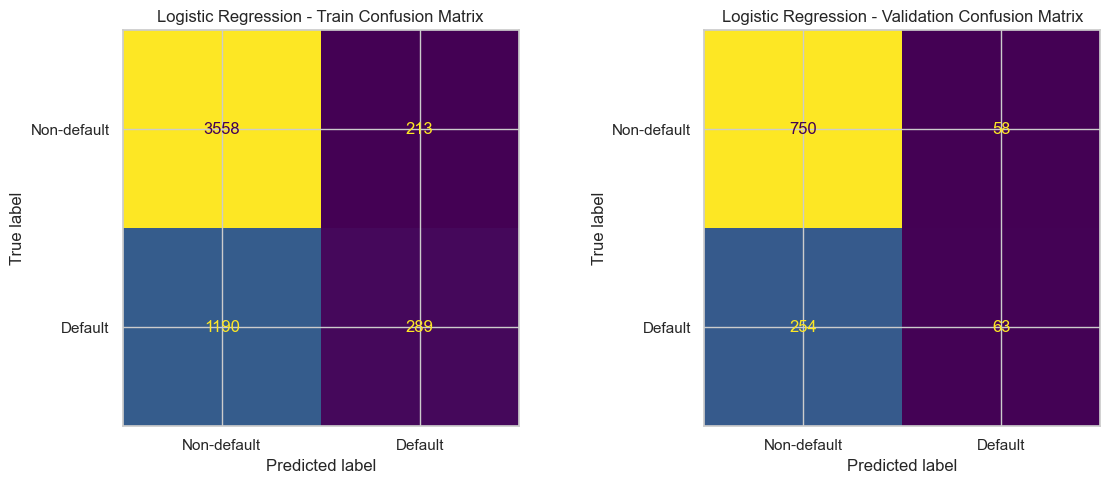

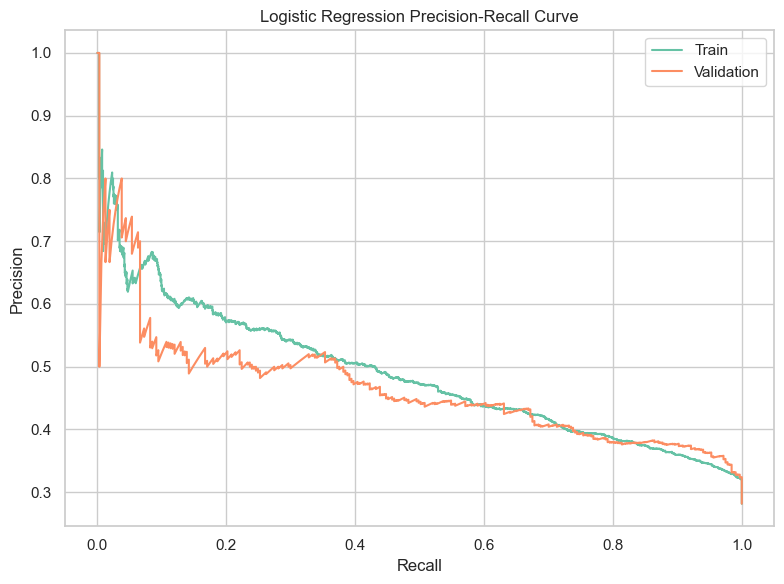

,feature,coefficient,abs_coefficient,direction
0,loan_amount_placeholder_flag,-1.919,1.919,negative
1,Maximum Open Credit,-1.246,1.246,negative
2,loan_to_income_ratio,0.342,0.342,positive
3,Current Loan Amount,-0.169,0.169,negative
4,Term_Short Term,-0.152,0.152,negative
5,Term_Long Term,0.152,0.152,positive
6,credit_utilization_proxy,0.150,0.150,positive
7,job_tenure_missing_flag,0.115,0.115,positive
8,Credit Score,-0.110,0.110,negative
9,Number of Open Accounts,0.109,0.109,positive


In [6]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

logreg_results = evaluate_binary_classifier(logreg, X_train, y_train, X_val, y_val, 'Logistic Regression')
display_model_evaluation(logreg_results, report_split='validation')
plot_confusion_matrices(logreg_results, splits=('train', 'validation'))
plot_precision_recall_curves(logreg_results, splits=('train', 'validation'))

logreg_coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg.named_steps['model'].coef_[0],
})
logreg_coefficients['abs_coefficient'] = logreg_coefficients['coefficient'].abs()
logreg_coefficients['direction'] = np.where(logreg_coefficients['coefficient'] >= 0, 'positive', 'negative')
logreg_coefficients = logreg_coefficients.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)
display(logreg_coefficients.head(20))


## Round 1: Full-Feature Random Forest


### Random Forest Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,Random Forest,train,5250,1.000,1.000,1.000,1.000
1,Random Forest,validation,1125,0.702,0.530,0.196,0.286


#### Validation Classification Report

,precision,recall,f1-score,support
0,0.747,0.932,0.829,808.000
1,0.530,0.196,0.286,317.000
accuracy,0.724,0.724,0.724,0.724
macro avg,0.638,0.564,0.558,"1,125.000"
weighted avg,0.686,0.724,0.676,"1,125.000"


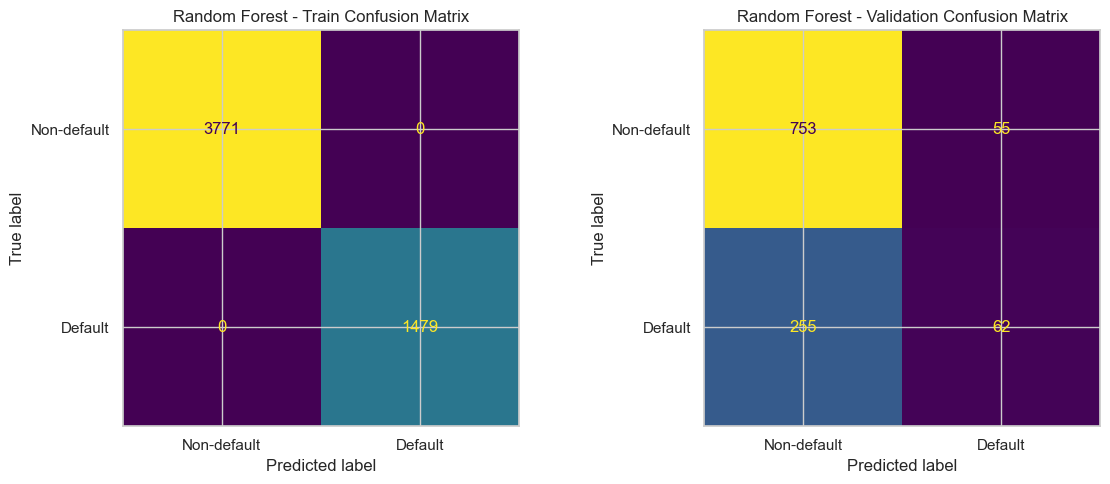

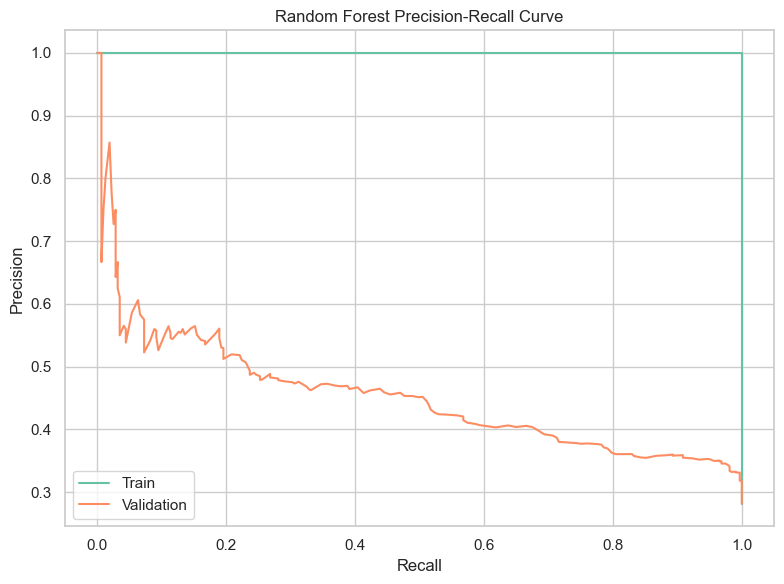

,feature,rf_importance
0,Current Loan Amount,0.081
1,loan_to_income_ratio,0.080
2,monthly_dti,0.074
3,credit_utilization_proxy,0.072
4,Years of Credit History,0.070
5,Maximum Open Credit,0.069
6,Monthly Debt,0.068
7,Current Credit Balance,0.067
8,Annual Income,0.063
9,Credit Score,0.063


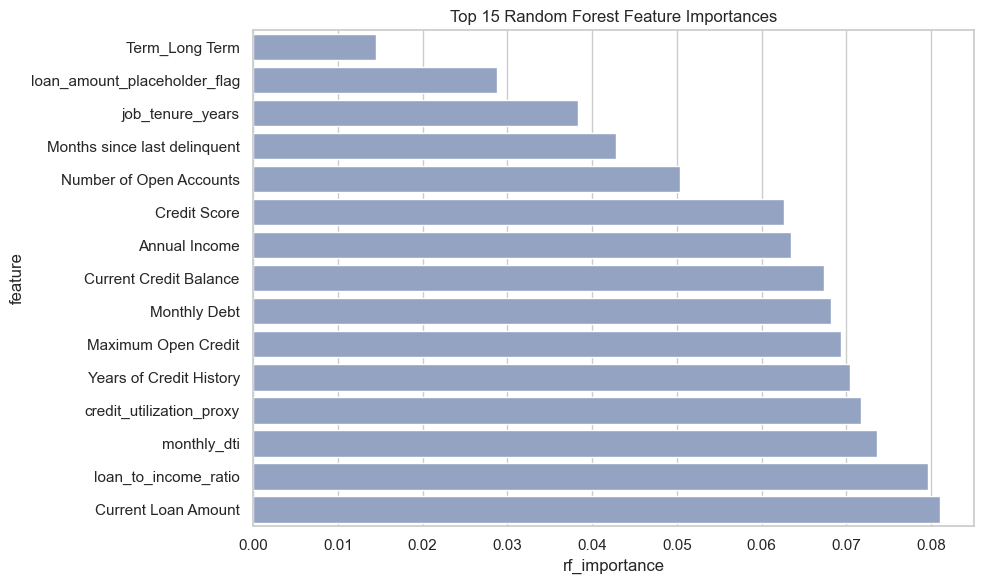

In [7]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_binary_classifier(rf_model, X_train, y_train, X_val, y_val, 'Random Forest')
display_model_evaluation(rf_results, report_split='validation')
plot_confusion_matrices(rf_results, splits=('train', 'validation'))
plot_precision_recall_curves(rf_results, splits=('train', 'validation'))

rf_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'rf_importance': rf_model.feature_importances_,
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)
display(rf_feature_importance.head(20))
plot_top_feature_scores(rf_feature_importance, 'rf_importance', 'Top 15 Random Forest Feature Importances', top_n=15)


## Round 1: Full-Feature XGBoost Baseline

The baseline XGBoost model uses the validation split for early stopping.


### XGBoost Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,XGBoost,train,5250,0.780,0.704,0.180,0.286
1,XGBoost,validation,1125,0.730,0.568,0.158,0.247


#### Validation Classification Report

,precision,recall,f1-score,support
0,0.743,0.953,0.835,808.000
1,0.568,0.158,0.247,317.000
accuracy,0.729,0.729,0.729,0.729
macro avg,0.655,0.555,0.541,"1,125.000"
weighted avg,0.693,0.729,0.669,"1,125.000"


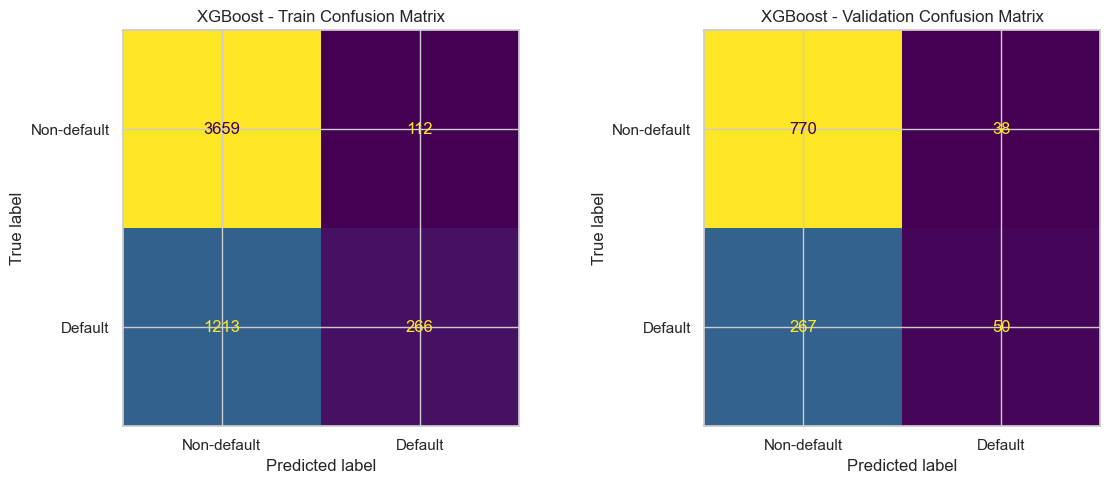

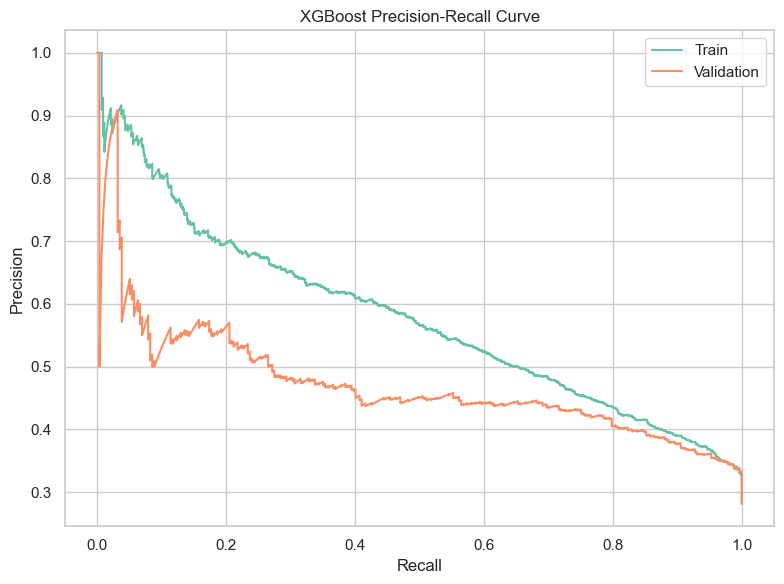

,feature,xgb_importance
0,loan_amount_placeholder_flag,0.151
1,Term_Long Term,0.108
2,Term_Short Term,0.106
3,loan_to_income_ratio,0.036
4,Credit Score,0.035
5,Annual Income,0.034
6,delinquency_missing_flag,0.033
7,credit_score_missing_flag,0.029
8,job_tenure_missing_flag,0.029
9,Bankruptcies,0.028


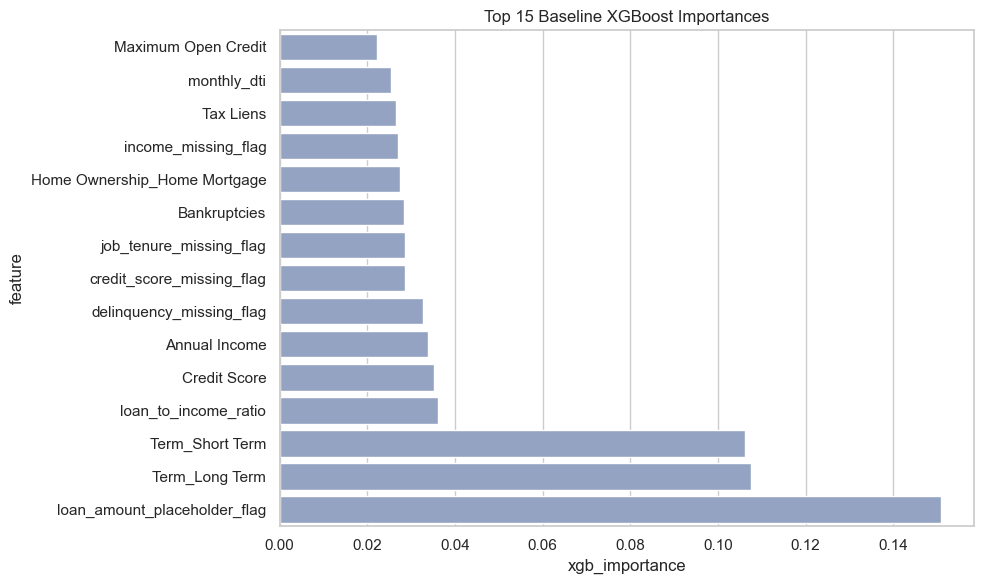

In [8]:
xgb_model = make_xgb_classifier(
    eval_metric='auc',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=1,
    early_stopping_rounds=30,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_results = evaluate_binary_classifier(xgb_model, X_train, y_train, X_val, y_val, 'XGBoost')
display_model_evaluation(xgb_results, report_split='validation')
plot_confusion_matrices(xgb_results, splits=('train', 'validation'))
plot_precision_recall_curves(xgb_results, splits=('train', 'validation'))

xgb_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'xgb_importance': xgb_model.feature_importances_,
}).sort_values('xgb_importance', ascending=False).reset_index(drop=True)
display(xgb_feature_importance.head(20))
plot_top_feature_scores(xgb_feature_importance, 'xgb_importance', 'Top 15 Baseline XGBoost Importances', top_n=15)


## Validation-Only XGBoost Optimization

Every approach below is trained on `X_train`, compared on `X_val`, and kept away from the test split until the final reporting section.


Starting XGBoost Grid Search...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_esti

### XGBoost Hyperparameter Tuning Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,XGBoost Hyperparameter Tuning,train,5250,1.000,0.999,0.974,0.986
1,XGBoost Hyperparameter Tuning,validation,1125,0.684,0.471,0.259,0.334


#### Validation Classification Report

,precision,recall,f1-score,support
0,0.753,0.886,0.814,808.000
1,0.471,0.259,0.334,317.000
accuracy,0.709,0.709,0.709,0.709
macro avg,0.612,0.572,0.574,"1,125.000"
weighted avg,0.674,0.709,0.679,"1,125.000"


...

### XGBoost Scale Pos Weight Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,XGBoost Scale Pos Weight,train,5250,1.000,0.957,1.000,0.978
1,XGBoost Scale Pos Weight,validation,1125,0.687,0.422,0.489,0.453


#### Validation Classification Report

,precision,recall,f1-score,support
0,0.786,0.738,0.761,808.000
1,0.422,0.489,0.453,317.000
accuracy,0.668,0.668,0.668,0.668
macro avg,0.604,0.613,0.607,"1,125.000"
weighted avg,0.684,0.668,0.674,"1,125.000"


Optimal validation threshold: 0.1019
Validation precision at optimal threshold: 0.3611
Validation recall at optimal threshold: 0.8738
Validation F1 at optimal threshold: 0.5111


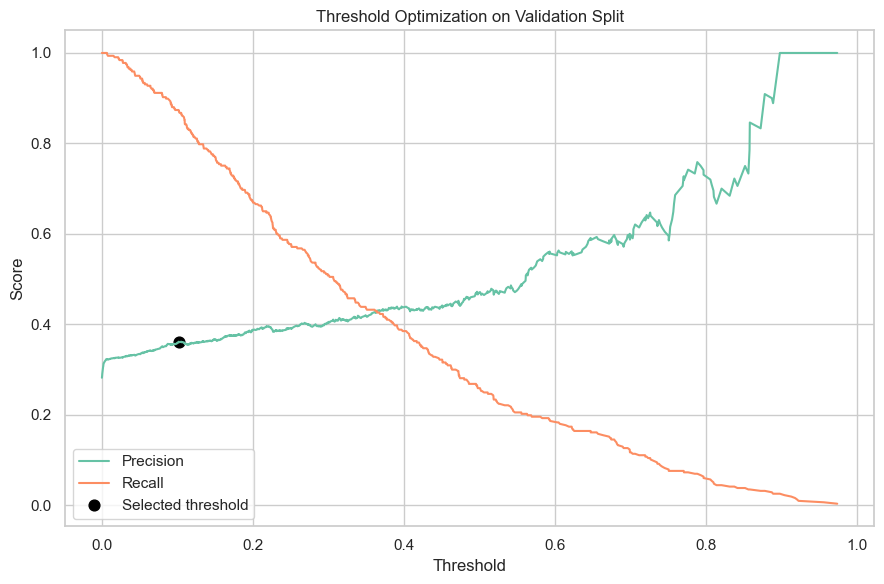

### XGBoost Threshold Optimization Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,XGBoost Threshold Optimization,train,5250,1.000,0.513,1.000,0.678
1,XGBoost Threshold Optimization,validation,1125,0.684,0.361,0.874,0.511


#### Validation Classification Report

,precision,recall,f1-score,support
0,0.888,0.394,0.545,808.000
1,0.361,0.874,0.511,317.000
accuracy,0.529,0.529,0.529,0.529
macro avg,0.625,0.634,0.528,"1,125.000"
weighted avg,0.740,0.529,0.536,"1,125.000"


Selected scale_pos_weight threshold: 0.0156
Validation precision at selected threshold: 0.3251
Validation recall at selected threshold: 1.0000
Validation F1 at selected threshold: 0.4907
Used fallback to max F1? False


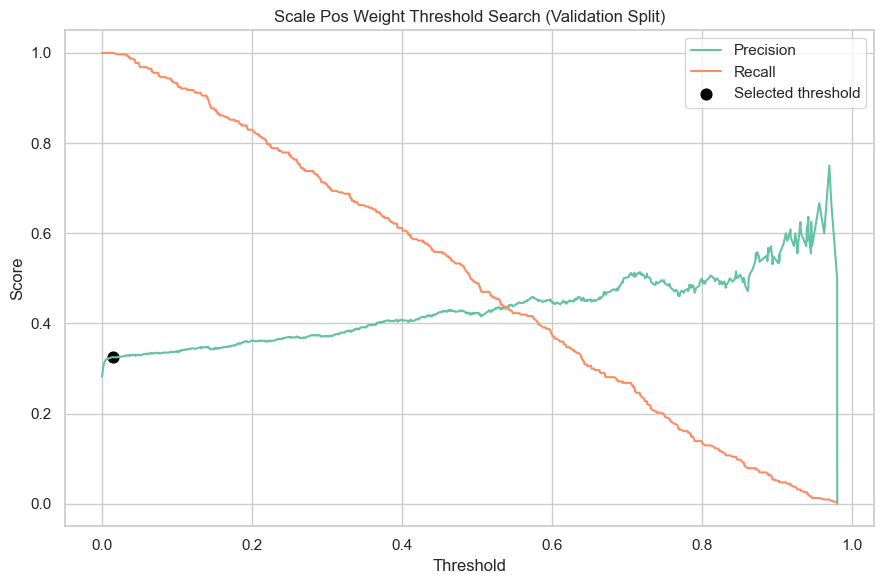

### XGBoost Scale Pos Weight + Threshold Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,XGBoost Scale Pos Weight + Threshold,train,5250,1.000,0.324,1.000,0.489
1,XGBoost Scale Pos Weight + Threshold,validation,1125,0.687,0.325,1.000,0.491


#### Validation Classification Report

,precision,recall,f1-score,support
0,1.000,0.186,0.313,808.000
1,0.325,1.000,0.491,317.000
accuracy,0.415,0.415,0.415,0.415
macro avg,0.663,0.593,0.402,"1,125.000"
weighted avg,0.810,0.415,0.363,"1,125.000"


### Validation-Only XGBoost Optimization Comparison

,model_name,split,samples,roc_auc,precision,recall,f1,approach
0,XGBoost Scale Pos Weight + Threshold,validation,1125,0.687,0.325,1.000,0.491,Scale Pos Weight + Threshold
1,XGBoost Threshold Optimization,validation,1125,0.684,0.361,0.874,0.511,Threshold Optimization
2,XGBoost Scale Pos Weight,validation,1125,0.687,0.422,0.489,0.453,Scale Pos Weight
3,XGBoost Class Weights,validation,1125,0.683,0.432,0.438,0.435,Class Weights
4,XGBoost SMOTE,validation,1125,0.679,0.435,0.328,0.374,SMOTE
5,XGBoost Hyperparameter Tuning,validation,1125,0.684,0.471,0.259,0.334,Hyperparameter Tuning
6,XGBoost,validation,1125,0.730,0.568,0.158,0.247,Baseline


Validation-selected best XGBoost approach: Scale Pos Weight + Threshold
Final selected XGBoost approach for reporting: Threshold Optimization
Final selected threshold: 0.1019


In [9]:

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'min_child_weight': [1, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_grid_base = make_xgb_classifier(eval_metric='logloss', verbosity=0)
xgb_grid_search = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='recall',
    n_jobs=1,
    verbose=2,
)

print('Starting XGBoost Grid Search...')
xgb_grid_search.fit(X_train, y_train)
print('\nBest Parameters:', xgb_grid_search.best_params_)
print('Best Cross-Validation Recall Score:', xgb_grid_search.best_score_)

xgb_tuned_model = xgb_grid_search.best_estimator_
xgb_tuned_results = evaluate_binary_classifier(
    xgb_tuned_model,
    X_train,
    y_train,
    X_val,
    y_val,
    'XGBoost Hyperparameter Tuning',
)
display_model_evaluation(xgb_tuned_results, report_split='validation')

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"Original training set - Default: {int(y_train.sum())}, Non-default: {int((y_train == 0).sum())}")
print(f"After SMOTE - Default: {int(y_train_smote.sum())}, Non-default: {int((y_train_smote == 0).sum())}")

xgb_smote_model = make_xgb_classifier(**xgb_grid_search.best_params_)
xgb_smote_model.fit(X_train_smote, y_train_smote, verbose=False)
xgb_smote_results = evaluate_binary_classifier(
    xgb_smote_model,
    X_train,
    y_train,
    X_val,
    y_val,
    'XGBoost SMOTE',
)
display_model_evaluation(xgb_smote_results, report_split='validation')

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(cls): float(weight) for cls, weight in zip(np.unique(y_train), class_weights)}
train_sample_weight = y_train.map(class_weight_dict).to_numpy()
print('Class weights:', class_weight_dict)

xgb_weighted_model = make_xgb_classifier(**xgb_grid_search.best_params_)
xgb_weighted_model.fit(X_train, y_train, sample_weight=train_sample_weight, verbose=False)
xgb_weighted_results = evaluate_binary_classifier(
    xgb_weighted_model,
    X_train,
    y_train,
    X_val,
    y_val,
    'XGBoost Class Weights',
)
display_model_evaluation(xgb_weighted_results, report_split='validation')

scale_pos_weight_grid = [1.5, 2.0, 2.55, 3.0, 4.0]
xgb_scale_pos_weight_search = GridSearchCV(
    estimator=make_xgb_classifier(**xgb_grid_search.best_params_, eval_metric='logloss', verbosity=0),
    param_grid={'scale_pos_weight': scale_pos_weight_grid},
    cv=5,
    scoring='recall',
    n_jobs=1,
    verbose=2,
)
print('Starting scale_pos_weight search...')
xgb_scale_pos_weight_search.fit(X_train, y_train)
scale_pos_weight_best_value = float(xgb_scale_pos_weight_search.best_params_['scale_pos_weight'])
print('Best scale_pos_weight:', scale_pos_weight_best_value)
print('Best scale_pos_weight CV recall:', xgb_scale_pos_weight_search.best_score_)

xgb_scale_pos_weight_model = xgb_scale_pos_weight_search.best_estimator_
xgb_scale_pos_weight_results = evaluate_binary_classifier(
    xgb_scale_pos_weight_model,
    X_train,
    y_train,
    X_val,
    y_val,
    'XGBoost Scale Pos Weight',
)
display_model_evaluation(xgb_scale_pos_weight_results, report_split='validation')

y_val_proba_tuned = xgb_tuned_model.predict_proba(X_val)[:, 1]
val_precisions, val_recalls, val_thresholds = precision_recall_curve(y_val, y_val_proba_tuned)
val_f1_scores = 2 * (val_precisions[:-1] * val_recalls[:-1]) / (val_precisions[:-1] + val_recalls[:-1] + 1e-10)
optimal_idx = int(np.argmax(val_f1_scores))
optimal_threshold = float(val_thresholds[optimal_idx])
print(f'Optimal validation threshold: {optimal_threshold:.4f}')
print(f'Validation precision at optimal threshold: {val_precisions[optimal_idx]:.4f}')
print(f'Validation recall at optimal threshold: {val_recalls[optimal_idx]:.4f}')
print(f'Validation F1 at optimal threshold: {val_f1_scores[optimal_idx]:.4f}')
plot_threshold_search(val_precisions, val_recalls, val_thresholds, optimal_idx)

xgb_threshold_results = evaluate_probability_model_with_threshold(
    xgb_tuned_model,
    X_train,
    y_train,
    X_val,
    y_val,
    'XGBoost Threshold Optimization',
    threshold=optimal_threshold,
)
display_model_evaluation(xgb_threshold_results, report_split='validation')

y_val_proba_scale_pos_weight = xgb_scale_pos_weight_model.predict_proba(X_val)[:, 1]
scale_pos_weight_threshold_search = select_threshold_with_precision_floor(
    *precision_recall_curve(y_val, y_val_proba_scale_pos_weight),
    precision_floor=0.30,
)
scale_pos_weight_optimal_threshold = float(scale_pos_weight_threshold_search['selected_row']['threshold'])
print(f'Selected scale_pos_weight threshold: {scale_pos_weight_optimal_threshold:.4f}')
print(f"Validation precision at selected threshold: {scale_pos_weight_threshold_search['selected_row']['precision']:.4f}")
print(f"Validation recall at selected threshold: {scale_pos_weight_threshold_search['selected_row']['recall']:.4f}")
print(f"Validation F1 at selected threshold: {scale_pos_weight_threshold_search['selected_row']['f1']:.4f}")
print('Used fallback to max F1?', scale_pos_weight_threshold_search['used_fallback'])
plot_threshold_search(
    scale_pos_weight_threshold_search['threshold_df']['precision'].to_numpy(),
    scale_pos_weight_threshold_search['threshold_df']['recall'].to_numpy(),
    scale_pos_weight_threshold_search['threshold_df']['threshold'].to_numpy(),
    scale_pos_weight_threshold_search['optimal_idx'],
    title='Scale Pos Weight Threshold Search (Validation Split)',
)

xgb_scale_pos_weight_threshold_results = evaluate_probability_model_with_threshold(
    xgb_scale_pos_weight_model,
    X_train,
    y_train,
    X_val,
    y_val,
    'XGBoost Scale Pos Weight + Threshold',
    threshold=scale_pos_weight_optimal_threshold,
)
display_model_evaluation(xgb_scale_pos_weight_threshold_results, report_split='validation')

xgb_optimization_results = {
    'Baseline': xgb_results,
    'Hyperparameter Tuning': xgb_tuned_results,
    'SMOTE': xgb_smote_results,
    'Class Weights': xgb_weighted_results,
    'Threshold Optimization': xgb_threshold_results,
    'Scale Pos Weight': xgb_scale_pos_weight_results,
    'Scale Pos Weight + Threshold': xgb_scale_pos_weight_threshold_results,
}
xgb_optimization_models = {
    'Baseline': xgb_model,
    'Hyperparameter Tuning': xgb_tuned_model,
    'SMOTE': xgb_smote_model,
    'Class Weights': xgb_weighted_model,
    'Threshold Optimization': xgb_tuned_model,
    'Scale Pos Weight': xgb_scale_pos_weight_model,
    'Scale Pos Weight + Threshold': xgb_scale_pos_weight_model,
}
xgb_optimization_thresholds = {
    'Baseline': None,
    'Hyperparameter Tuning': None,
    'SMOTE': None,
    'Class Weights': None,
    'Threshold Optimization': optimal_threshold,
    'Scale Pos Weight': None,
    'Scale Pos Weight + Threshold': scale_pos_weight_optimal_threshold,
}

xgb_optimization_summary = summarize_optimization_results(xgb_optimization_results)
validation_xgb_optimization_comparison = xgb_optimization_summary[
    xgb_optimization_summary['split'] == 'validation'
].sort_values(['recall', 'precision', 'f1', 'roc_auc'], ascending=False).reset_index(drop=True)
display(Markdown('### Validation-Only XGBoost Optimization Comparison'))
display(validation_xgb_optimization_comparison)

best_xgb_approach = choose_best_approach(validation_xgb_optimization_comparison)
final_xgb_approach = 'Threshold Optimization'
final_xgb_model = xgb_tuned_model
final_xgb_threshold = optimal_threshold
final_xgb_dev_results = xgb_threshold_results

print(f'Validation-selected best XGBoost approach: {best_xgb_approach}')
print(f'Final selected XGBoost approach for reporting: {final_xgb_approach}')
print(f'Final selected threshold: {final_xgb_threshold:.4f}')


## Build the Reduced Feature-Family Shortlist

Reduced-feature evidence is built only from training-derived correlation and model importance.


In [10]:
feature_evidence, family_evidence = build_family_evidence(
    correlation_table,
    logreg_coefficients,
    rf_feature_importance,
    xgb_feature_importance,
)

selected_feature_families = family_evidence.loc[
    (family_evidence['support_count'] >= 2) & (family_evidence['family'] != 'loan_amount_placeholder_flag'),
    'family'
].tolist()
selected_feature_columns = select_feature_columns_by_family(X_train.columns, selected_feature_families)

display(feature_evidence)
display(family_evidence)
print('Selected feature families:', selected_feature_families)
print('Selected feature column count:', len(selected_feature_columns))


,feature,abs_correlation,abs_coefficient,rf_importance,xgb_importance,family
0,loan_amount_placeholder_flag,0.228,1.919,0.029,0.151,loan_amount_placeholder_flag
1,Term_Long Term,0.184,0.152,0.015,0.108,Term
2,Term_Short Term,0.184,0.152,0.014,0.106,Term
3,Credit Score,0.162,0.110,0.063,0.035,Credit Score
4,loan_to_income_ratio,0.146,0.342,0.080,0.036,loan_to_income_ratio
5,monthly_dti,0.113,0.089,0.074,0.025,monthly_dti
6,Current Loan Amount,0.091,0.169,0.081,0.017,Current Loan Amount
7,Annual Income,0.087,0.049,0.063,0.034,Annual Income
8,credit_utilization_proxy,0.083,0.150,0.072,0.021,credit_utilization_proxy
9,income_missing_flag,0.072,0.048,0.006,0.027,income_missing_flag


,family,abs_correlation,logreg_abs_coefficient,rf_importance,xgb_importance,corr_signal,logreg_signal,rf_signal,xgb_signal,support_count
0,loan_amount_placeholder_flag,0.228,1.919,0.029,0.151,True,True,True,True,4
1,Purpose,0.040,0.590,0.029,0.077,True,True,True,True,4
2,loan_to_income_ratio,0.146,0.342,0.080,0.036,True,True,True,True,4
3,Credit Score,0.162,0.110,0.063,0.035,True,True,True,True,4
4,Annual Income,0.087,0.049,0.063,0.034,True,True,True,True,4
5,monthly_dti,0.113,0.089,0.074,0.025,True,True,True,True,4
6,Term,0.184,0.304,0.029,0.214,True,True,False,True,3
7,Home Ownership,0.065,0.170,0.025,0.069,True,True,False,True,3
8,credit_score_missing_flag,0.072,0.048,0.006,0.029,True,True,False,True,3
9,job_tenure_missing_flag,0.042,0.115,0.006,0.029,True,True,False,True,3


Selected feature families: ['Purpose', 'loan_to_income_ratio', 'Credit Score', 'Annual Income', 'monthly_dti', 'Term', 'Home Ownership', 'credit_score_missing_flag', 'job_tenure_missing_flag', 'income_missing_flag', 'Maximum Open Credit', 'credit_utilization_proxy', 'Current Loan Amount', 'Tax Liens', 'Number of Open Accounts']
Selected feature column count: 32


## Validation-Only Reduced-Feature Round

The reduced-feature comparison also stays away from the test split.


In [11]:
X_train_reduced = X_train[selected_feature_columns].copy()
X_val_reduced = X_val[selected_feature_columns].copy()

logreg_reduced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
logreg_reduced.fit(X_train_reduced, y_train)

rf_model_reduced = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_model_reduced.fit(X_train_reduced, y_train)

xgb_model_reduced = make_xgb_classifier(
    eval_metric='auc',
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=1,
    early_stopping_rounds=30,
)
xgb_model_reduced.fit(X_train_reduced, y_train, eval_set=[(X_val_reduced, y_val)], verbose=False)

full_round_results = {
    'Logistic Regression': logreg_results,
    'Random Forest': rf_results,
    'XGBoost': xgb_results,
}
reduced_round_results = {
    'Logistic Regression': evaluate_binary_classifier(logreg_reduced, X_train_reduced, y_train, X_val_reduced, y_val, 'Logistic Regression'),
    'Random Forest': evaluate_binary_classifier(rf_model_reduced, X_train_reduced, y_train, X_val_reduced, y_val, 'Random Forest'),
    'XGBoost': evaluate_binary_classifier(xgb_model_reduced, X_train_reduced, y_train, X_val_reduced, y_val, 'XGBoost'),
}

full_round_summary = summarize_round_results(full_round_results, 'full')
reduced_round_summary = summarize_round_results(reduced_round_results, 'reduced')

validation_model_comparison = full_round_summary[full_round_summary['split'] == 'validation'].reset_index(drop=True)
validation_reduced_model_comparison = reduced_round_summary[reduced_round_summary['split'] == 'validation'].reset_index(drop=True)
validation_reduced_vs_full_comparison = build_round_comparison(full_round_summary, reduced_round_summary, 'validation')
validation_reduced_vs_full_comparison['reduction_effect'] = validation_reduced_vs_full_comparison.apply(interpret_reduction_effect, axis=1)

display(Markdown('### Full-Feature Model Comparison (Validation Split)'))
display(validation_model_comparison)
display(Markdown('### Reduced-Feature Model Comparison (Validation Split)'))
display(validation_reduced_model_comparison)
display(Markdown('### Full vs Reduced Comparison on Validation Split'))
display(validation_reduced_vs_full_comparison)


### Full-Feature Model Comparison (Validation Split)

,model_name,split,samples,roc_auc,precision,recall,f1,round_name
0,Logistic Regression,validation,1125,0.720,0.521,0.199,0.288,full
1,Random Forest,validation,1125,0.702,0.530,0.196,0.286,full
2,XGBoost,validation,1125,0.730,0.568,0.158,0.247,full


### Reduced-Feature Model Comparison (Validation Split)

,model_name,split,samples,roc_auc,precision,recall,f1,round_name
0,Logistic Regression,validation,1125,0.678,0.505,0.145,0.225,reduced
1,Random Forest,validation,1125,0.693,0.519,0.215,0.304,reduced
2,XGBoost,validation,1125,0.725,0.576,0.155,0.244,reduced


### Full vs Reduced Comparison on Validation Split

,model_name,split,samples_full,roc_auc_full,precision_full,recall_full,f1_full,round_name_full,samples_reduced,roc_auc_reduced,precision_reduced,recall_reduced,f1_reduced,round_name_reduced,roc_auc_delta,precision_delta,recall_delta,f1_delta,reduction_effect
0,Logistic Regression,validation,1125,0.720,0.521,0.199,0.288,full,1125,0.678,0.505,0.145,0.225,reduced,-0.042,-0.015,-0.054,-0.062,hurt
1,Random Forest,validation,1125,0.702,0.530,0.196,0.286,full,1125,0.693,0.519,0.215,0.304,reduced,-0.008,-0.011,0.019,0.018,hurt
2,XGBoost,validation,1125,0.730,0.568,0.158,0.247,full,1125,0.725,0.576,0.155,0.244,reduced,-0.005,0.008,-0.003,-0.003,maintained


## Final Held-Out Test Report

The selected final model is evaluated on the test split only here.


### Final XGBoost (Threshold Optimization) Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,Final XGBoost (Threshold Optimization),train,5250,1.000,0.513,1.000,0.678
1,Final XGBoost (Threshold Optimization),validation,1125,0.684,0.361,0.874,0.511
2,Final XGBoost (Threshold Optimization),test,1125,0.678,0.345,0.874,0.495


#### Test Classification Report

,precision,recall,f1-score,support
0,0.876,0.350,0.500,808.000
1,0.345,0.874,0.495,317.000
accuracy,0.498,0.498,0.498,0.498
macro avg,0.611,0.612,0.498,"1,125.000"
weighted avg,0.727,0.498,0.499,"1,125.000"


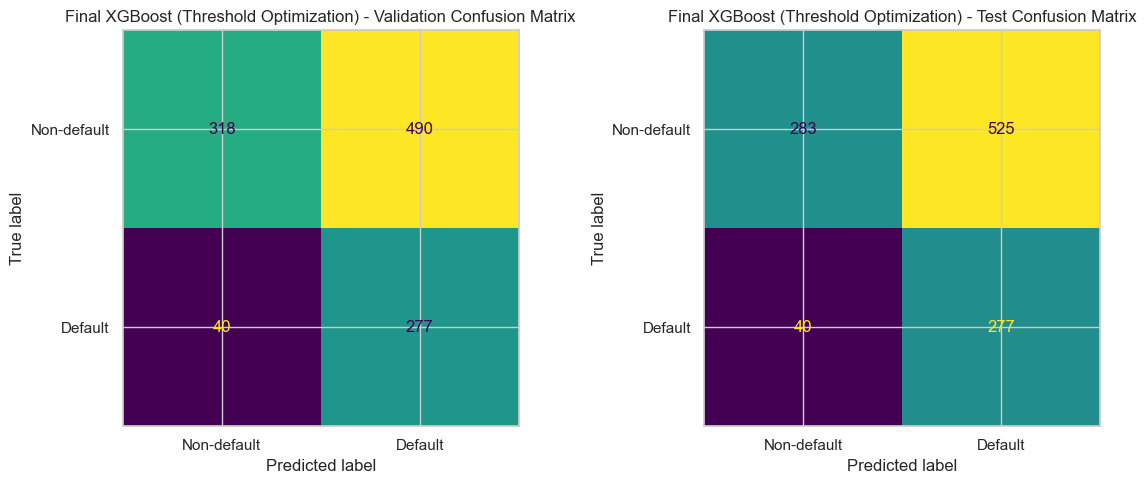

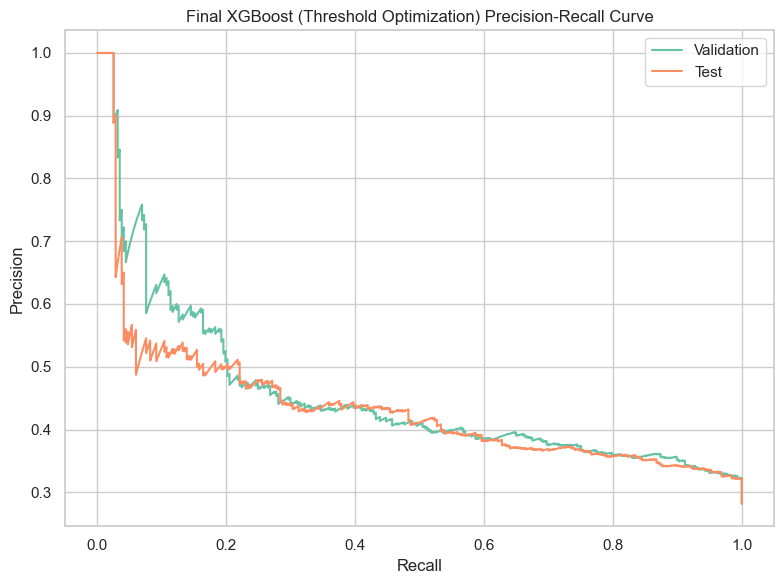

,feature,xgb_importance
0,loan_amount_placeholder_flag,0.319
1,Term_Long Term,0.063
2,Purpose_business loan,0.038
3,Purpose_medical bills,0.038
4,job_tenure_missing_flag,0.032
5,Number of Credit Problems,0.026
6,credit_score_missing_flag,0.024
7,Tax Liens,0.024
8,Home Ownership_Own Home,0.023
9,Purpose_home improvements,0.023


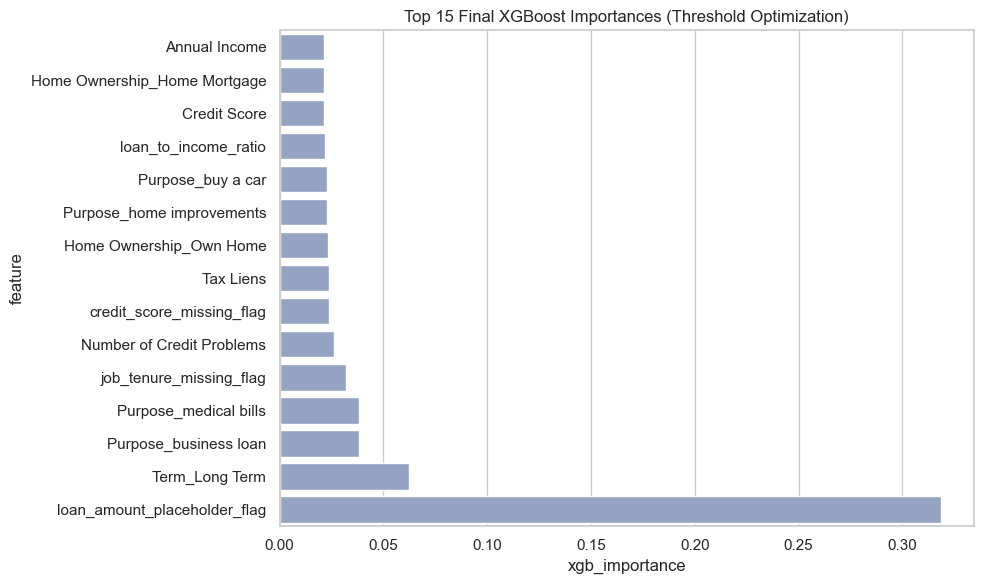

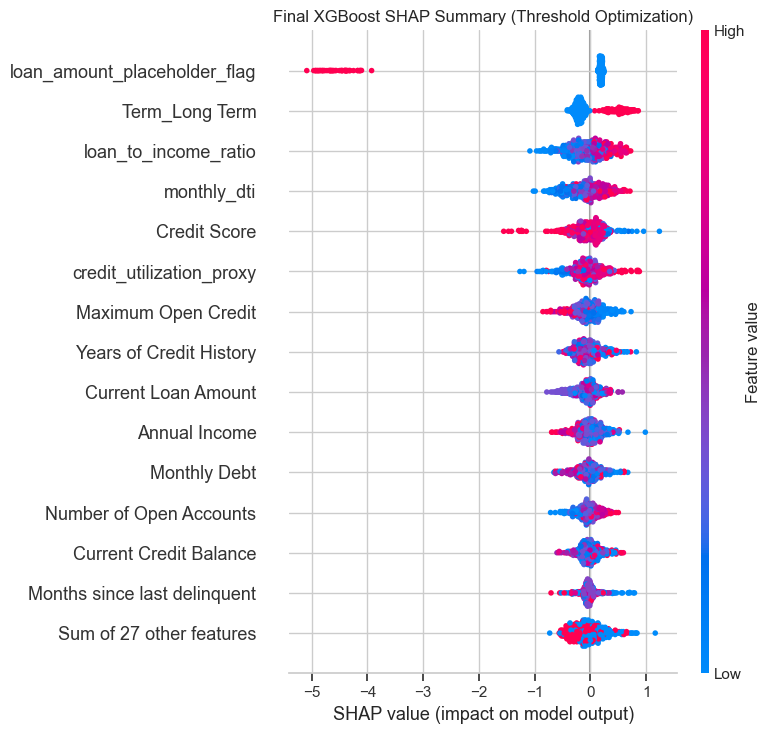

In [12]:
final_test_results = evaluate_final_model(
    final_xgb_model,
    final_xgb_threshold,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    f'Final XGBoost ({final_xgb_approach})',
)
display_model_evaluation(final_test_results, report_split='test')
plot_confusion_matrices(final_test_results, splits=('validation', 'test'))
plot_precision_recall_curves(final_test_results, splits=('validation', 'test'))

final_xgb_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'xgb_importance': final_xgb_model.feature_importances_,
}).sort_values('xgb_importance', ascending=False).reset_index(drop=True)
display(final_xgb_feature_importance)
plot_top_feature_scores(
    final_xgb_feature_importance,
    'xgb_importance',
    f'Top 15 Final XGBoost Importances ({final_xgb_approach})',
    top_n=15,
)

xgb_best_shap_values = plot_tree_shap(
    final_xgb_model,
    X_test,
    sample_size=500,
    title=f'Final XGBoost SHAP Summary ({final_xgb_approach})',
)


## Save Final Model and Score New Applications

The final threshold-optimized XGBoost model is saved together with its preprocessing artifacts and then used to score `data/new-applications.csv`.


In [13]:
MODEL_BUNDLE_PATH = Path('credit_default_threshold_xgb_bundle.joblib')
SCORED_OUTPUT_PATH = Path('data/new-applications-scored.csv')
NEW_APPLICATIONS_PATH = Path('data/new-applications.csv')

model_bundle = {
    'model': final_xgb_model,
    'threshold': final_xgb_threshold,
    'preprocessor_artifacts': preprocessor_artifacts,
    'feature_columns': X_train.columns.tolist(),
    'model_name': f'Final XGBoost ({final_xgb_approach})',
    'target_name': TARGET,
}
joblib.dump(model_bundle, MODEL_BUNDLE_PATH)
print(f'Model bundle saved to: {MODEL_BUNDLE_PATH.resolve()}')

loaded_model_bundle = joblib.load(MODEL_BUNDLE_PATH)
new_applications_raw = pd.read_csv(NEW_APPLICATIONS_PATH)
prepared_new_applications, encoded_new_applications = transform_split(
    new_applications_raw,
    loaded_model_bundle['preprocessor_artifacts'],
)
encoded_new_applications = encoded_new_applications.reindex(
    columns=loaded_model_bundle['feature_columns'],
    fill_value=0,
)

predicted_default_probability = loaded_model_bundle['model'].predict_proba(encoded_new_applications)[:, 1]
predicted_default_label = (predicted_default_probability >= loaded_model_bundle['threshold']).astype(int)

scored_new_applications = new_applications_raw.copy()
scored_new_applications['predicted_default_probability'] = predicted_default_probability
scored_new_applications['predicted_default_label'] = predicted_default_label
scored_new_applications = scored_new_applications.sort_values(
    'predicted_default_probability',
    ascending=False,
).reset_index(drop=True)

prepared_new_applications = prepared_new_applications.reindex(scored_new_applications.index)
encoded_new_applications = encoded_new_applications.reindex(scored_new_applications.index)

scored_new_applications.to_csv(SCORED_OUTPUT_PATH, index=False)
print(f'Scored applications saved to: {SCORED_OUTPUT_PATH.resolve()}')

scoring_summary = pd.DataFrame({
    'metric': [
        'applications_scored',
        'predicted_default_count',
        'predicted_non_default_count',
        'mean_predicted_probability',
    ],
    'value': [
        int(scored_new_applications.shape[0]),
        int(scored_new_applications['predicted_default_label'].sum()),
        int((scored_new_applications['predicted_default_label'] == 0).sum()),
        float(scored_new_applications['predicted_default_probability'].mean()),
    ],
})
display(scoring_summary)
display(scored_new_applications.head(10))


Model bundle saved to: /Users/abhishek/Desktop/Assignments/FinTech A1/credit_default_threshold_xgb_bundle.joblib
Scored applications saved to: /Users/abhishek/Desktop/Assignments/FinTech A1/data/new-applications-scored.csv


,metric,value
0,applications_scored,"2,500.000"
1,predicted_default_count,"1,709.000"
2,predicted_non_default_count,791.000
3,mean_predicted_probability,0.245


,Id,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,predicted_default_probability,predicted_default_label
0,7867,Home Mortgage,NaN,10+ years,0.000,7.000,15.500,"327,008.000",0.000,40.000,0.000,home improvements,Long Term,"784,564.000","110,979.000","20,158.000",NaN,0.959,1
1,8117,Rent,"704,843.000",4 years,0.000,21.000,9.000,"88,682.000",0.000,8.000,0.000,other,Short Term,"86,482.000","46,721.000","6,344.000",676.000,0.937,1
2,7958,Rent,NaN,7 years,0.000,10.000,8.800,"204,842.000",0.000,24.000,0.000,debt consolidation,Long Term,"296,758.000","62,263.000","18,251.000",NaN,0.936,1
3,7576,Own Home,"1,365,530.000",9 years,0.000,15.000,21.500,"2,053,260.000",0.000,NaN,0.000,medical bills,Long Term,"527,054.000","734,122.000","21,280.000",667.000,0.936,1
4,8663,Rent,"1,499,024.000",10+ years,0.000,13.000,18.700,"1,227,556.000",0.000,NaN,0.000,business loan,Long Term,"500,104.000","181,279.000","4,784.000",586.000,0.923,1
5,8095,Home Mortgage,NaN,10+ years,0.000,12.000,16.000,"364,012.000",0.000,13.000,0.000,debt consolidation,Long Term,"558,470.000","214,092.000","51,190.000",NaN,0.910,1
6,9357,Home Mortgage,"1,420,725.000",10+ years,0.000,19.000,12.900,"1,088,428.000",0.000,NaN,0.000,debt consolidation,Long Term,"524,216.000","689,035.000","35,281.000",585.000,0.909,1
7,9284,Rent,"718,200.000",1 year,0.000,10.000,15.400,"485,606.000",1.000,79.000,1.000,debt consolidation,Long Term,"325,424.000","319,561.000","17,417.000",683.000,0.906,1
8,9358,Rent,"745,256.000",< 1 year,0.000,10.000,9.600,"238,062.000",0.000,NaN,0.000,debt consolidation,Long Term,"297,110.000","111,853.000","12,234.000",686.000,0.905,1
9,7872,Rent,"163,305.000",NaN,0.000,14.000,26.700,"124,366.000",0.000,50.000,0.000,other,Short Term,"31,064.000","64,771.000","4,164.000",653.000,0.896,1


## Fairness Assessment and Mitigation Check

This section uses the **held-out test split only** to review whether the final threshold-optimized XGBoost workflow behaves differently across `Home Ownership` groups.

`Home Ownership` is treated here as a **proxy / socioeconomic sensitivity check**, not as a protected attribute. The purpose is governance and internal review, not a claim of legal or regulatory fairness certification. Small groups are flagged explicitly so unstable estimates are not overinterpreted.

### Group Size and Prevalence

,Home Ownership,sample_count,small_sample_flag,actual_default_rate,predicted_default_rate
0,Home Mortgage,556,False,0.273,0.653
1,Rent,476,False,0.296,0.771
2,Own Home,93,False,0.258,0.774


### Error-Rate Fairness

,Home Ownership,sample_count,precision,recall,false_positive_rate,false_negative_rate
0,Home Mortgage,556,0.344,0.822,0.589,0.178
1,Rent,476,0.351,0.915,0.710,0.085
2,Own Home,93,0.319,0.958,0.710,0.042


### Decision-Band Fairness

,Home Ownership,sample_count,approval_rate,manual_review_rate,reject_escalate_rate
0,Home Mortgage,556,0.344,0.275,0.381
1,Rent,476,0.227,0.317,0.456
2,Own Home,93,0.215,0.290,0.495


### Gap Summary

,metric,gap
0,Predicted default rate gap,0.121
1,Approval rate gap,0.128
2,False positive rate gap,0.121
3,False negative rate gap,0.136


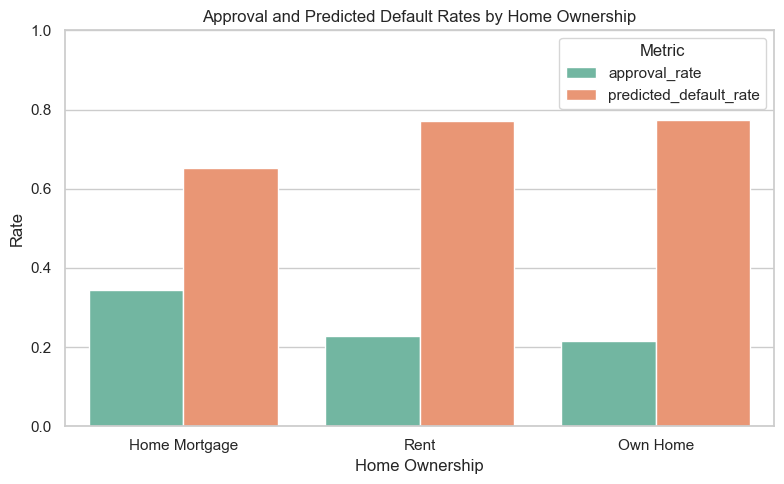

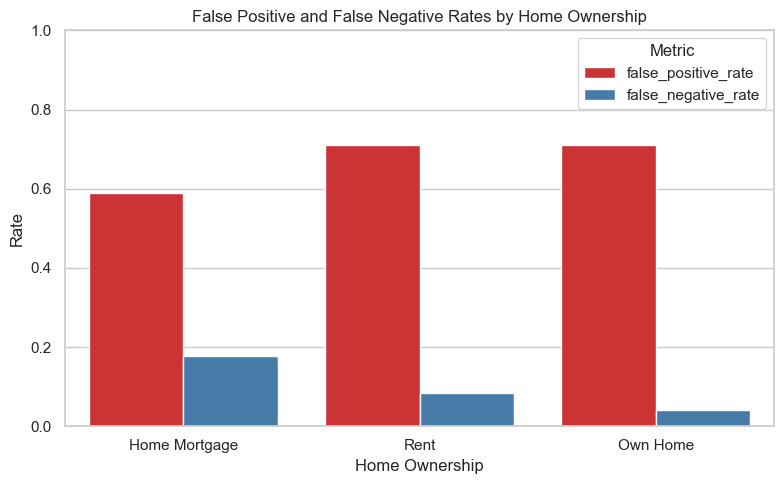

In [16]:
import json
from sklearn.metrics import confusion_matrix

FAIRNESS_SUMMARY_PATH = Path('fairness_summary.json')


def normalize_home_ownership(series):
    return series.replace({'Have Mortgage': 'Home Mortgage'}).fillna('Missing')


def assign_decision_band(probability):
    if probability < LOW_RISK_CUTOFF:
        return 'Recommend Approve'
    if probability < HIGH_RISK_CUTOFF:
        return 'Manual Review'
    return 'Recommend Reject / Escalate'


def safe_divide(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def build_fairness_metrics(fairness_df, group_col='Home Ownership'):
    rows = []
    for group_name, group_df in fairness_df.groupby(group_col, dropna=False):
        y_true = group_df['actual_default'].astype(int).to_numpy()
        y_pred = group_df['predicted_default'].astype(int).to_numpy()
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            group_col: group_name,
            'sample_count': int(len(group_df)),
            'small_sample_flag': bool(len(group_df) < 50),
            'actual_default_rate': float(group_df['actual_default'].mean()),
            'predicted_default_rate': float(group_df['predicted_default'].mean()),
            'approval_rate': float((group_df['decision_band'] == 'Recommend Approve').mean()),
            'manual_review_rate': float((group_df['decision_band'] == 'Manual Review').mean()),
            'reject_escalate_rate': float((group_df['decision_band'] == 'Recommend Reject / Escalate').mean()),
            'precision': safe_divide(tp, tp + fp),
            'recall': safe_divide(tp, tp + fn),
            'false_positive_rate': safe_divide(fp, fp + tn),
            'false_negative_rate': safe_divide(fn, fn + tp),
        })
    return pd.DataFrame(rows).sort_values(['sample_count', group_col], ascending=[False, True]).reset_index(drop=True)


def build_gap_summary(metrics_df):
    gap_metrics = {
        'predicted_default_rate': 'Predicted default rate gap',
        'approval_rate': 'Approval rate gap',
        'false_positive_rate': 'False positive rate gap',
        'false_negative_rate': 'False negative rate gap',
    }
    rows = []
    for metric_name, label in gap_metrics.items():
        rows.append({
            'metric': label,
            'gap': float(metrics_df[metric_name].max() - metrics_df[metric_name].min()),
        })
    return pd.DataFrame(rows)


fairness_test_df = X_test_raw[['Home Ownership']].copy()
fairness_test_df['Home Ownership'] = normalize_home_ownership(fairness_test_df['Home Ownership'])
fairness_test_df['actual_default'] = y_test.to_numpy()
fairness_test_df['predicted_default_probability'] = final_test_results['split_results']['test']['y_score']
fairness_test_df['predicted_default'] = (fairness_test_df['predicted_default_probability'] >= final_xgb_threshold).astype(int)
fairness_test_df['decision_band'] = fairness_test_df['predicted_default_probability'].apply(assign_decision_band)

fairness_metrics = build_fairness_metrics(fairness_test_df)
fairness_group_summary = fairness_metrics[[
    'Home Ownership', 'sample_count', 'small_sample_flag', 'actual_default_rate', 'predicted_default_rate'
]].copy()
fairness_error_rate_table = fairness_metrics[[
    'Home Ownership', 'sample_count', 'precision', 'recall', 'false_positive_rate', 'false_negative_rate'
]].copy()
fairness_decision_band_table = fairness_metrics[[
    'Home Ownership', 'sample_count', 'approval_rate', 'manual_review_rate', 'reject_escalate_rate'
]].copy()
fairness_gap_summary = build_gap_summary(fairness_metrics)

display(Markdown('### Group Size and Prevalence'))
display(fairness_group_summary)
display(Markdown('### Error-Rate Fairness'))
display(fairness_error_rate_table)
display(Markdown('### Decision-Band Fairness'))
display(fairness_decision_band_table)
display(Markdown('### Gap Summary'))
display(fairness_gap_summary)

if fairness_group_summary['small_sample_flag'].any():
    small_groups = fairness_group_summary.loc[fairness_group_summary['small_sample_flag'], 'Home Ownership'].tolist()
    print('Small-sample caution for groups:', small_groups)

plot_group_summary = fairness_metrics[['Home Ownership', 'approval_rate', 'predicted_default_rate']].copy()
plot_group_summary = plot_group_summary.melt(id_vars='Home Ownership', var_name='metric', value_name='value')
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_group_summary, x='Home Ownership', y='value', hue='metric', palette='Set2')
plt.title('Approval and Predicted Default Rates by Home Ownership')
plt.ylabel('Rate')
plt.xlabel('Home Ownership')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

error_rate_plot = fairness_metrics[['Home Ownership', 'false_positive_rate', 'false_negative_rate']].copy()
error_rate_plot = error_rate_plot.melt(id_vars='Home Ownership', var_name='metric', value_name='value')
plt.figure(figsize=(8, 5))
sns.barplot(data=error_rate_plot, x='Home Ownership', y='value', hue='metric', palette='Set1')
plt.title('False Positive and False Negative Rates by Home Ownership')
plt.ylabel('Rate')
plt.xlabel('Home Ownership')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

**Interpretation guidance:**

- Differences across `Home Ownership` groups should be read as an internal **sensitivity / proxy fairness check**, not as a legal fairness conclusion.
- The most important fairness questions here are whether some groups face meaningfully lower approval rates or higher false positive rates than others.
- If small groups appear in the table, those estimates should be treated as directional only.
- Any material disparity should feed into governance decisions such as tighter review of policy overrides, better adverse-action explanation coverage, and periodic revalidation of the feature set.

## Mitigation Sensitivity Check: Remove `Home Ownership`

A practical mitigation test is to remove all `Home Ownership` encoded features and see whether the final threshold-based XGBoost workflow materially changes in performance or fairness gaps. This gives the report a measured basis for deciding whether the feature is worth retaining.

In [17]:
home_ownership_feature_columns = [col for col in X_train.columns if col.startswith('Home Ownership_')]

X_train_no_home = X_train.drop(columns=home_ownership_feature_columns)
X_val_no_home = X_val.drop(columns=home_ownership_feature_columns)
X_test_no_home = X_test.drop(columns=home_ownership_feature_columns)

xgb_home_ownership_ablation_model = make_xgb_classifier(**xgb_grid_search.best_params_)
xgb_home_ownership_ablation_model.fit(X_train_no_home, y_train, verbose=False)

y_val_proba_no_home = xgb_home_ownership_ablation_model.predict_proba(X_val_no_home)[:, 1]
val_precisions_no_home, val_recalls_no_home, val_thresholds_no_home = precision_recall_curve(y_val, y_val_proba_no_home)
val_f1_scores_no_home = 2 * (val_precisions_no_home[:-1] * val_recalls_no_home[:-1]) / (
    val_precisions_no_home[:-1] + val_recalls_no_home[:-1] + 1e-10
)
home_ownership_ablation_optimal_idx = int(np.argmax(val_f1_scores_no_home))
home_ownership_ablation_threshold = float(val_thresholds_no_home[home_ownership_ablation_optimal_idx])

home_ownership_ablation_results = evaluate_final_model(
    xgb_home_ownership_ablation_model,
    home_ownership_ablation_threshold,
    X_train_no_home,
    y_train,
    X_val_no_home,
    y_val,
    X_test_no_home,
    y_test,
    'Final XGBoost without Home Ownership',
)
display_model_evaluation(home_ownership_ablation_results, report_split='test')

fairness_test_df_no_home = X_test_raw[['Home Ownership']].copy()
fairness_test_df_no_home['Home Ownership'] = normalize_home_ownership(fairness_test_df_no_home['Home Ownership'])
fairness_test_df_no_home['actual_default'] = y_test.to_numpy()
fairness_test_df_no_home['predicted_default_probability'] = home_ownership_ablation_results['split_results']['test']['y_score']
fairness_test_df_no_home['predicted_default'] = (
    fairness_test_df_no_home['predicted_default_probability'] >= home_ownership_ablation_threshold
).astype(int)
fairness_test_df_no_home['decision_band'] = fairness_test_df_no_home['predicted_default_probability'].apply(assign_decision_band)

home_ownership_ablation_fairness_metrics = build_fairness_metrics(fairness_test_df_no_home)
home_ownership_ablation_gap_summary = build_gap_summary(home_ownership_ablation_fairness_metrics)

baseline_test_row = final_test_results['metrics_table'].query("split == 'test'").iloc[0]
ablation_test_row = home_ownership_ablation_results['metrics_table'].query("split == 'test'").iloc[0]

home_ownership_ablation_performance_comparison = pd.DataFrame([
    {
        'variant': 'Final threshold model (with Home Ownership)',
        'roc_auc': float(baseline_test_row['roc_auc']),
        'precision': float(baseline_test_row['precision']),
        'recall': float(baseline_test_row['recall']),
        'f1': float(baseline_test_row['f1']),
    },
    {
        'variant': 'Final threshold model (without Home Ownership)',
        'roc_auc': float(ablation_test_row['roc_auc']),
        'precision': float(ablation_test_row['precision']),
        'recall': float(ablation_test_row['recall']),
        'f1': float(ablation_test_row['f1']),
    },
])

def gap_map(gap_df):
    return dict(zip(gap_df['metric'], gap_df['gap']))

baseline_gap_map = gap_map(fairness_gap_summary)
ablation_gap_map = gap_map(home_ownership_ablation_gap_summary)

home_ownership_ablation_fairness_comparison = pd.DataFrame([
    {
        'metric': 'Approval rate gap',
        'with_home_ownership': float(baseline_gap_map['Approval rate gap']),
        'without_home_ownership': float(ablation_gap_map['Approval rate gap']),
    },
    {
        'metric': 'False positive rate gap',
        'with_home_ownership': float(baseline_gap_map['False positive rate gap']),
        'without_home_ownership': float(ablation_gap_map['False positive rate gap']),
    },
    {
        'metric': 'False negative rate gap',
        'with_home_ownership': float(baseline_gap_map['False negative rate gap']),
        'without_home_ownership': float(ablation_gap_map['False negative rate gap']),
    },
    {
        'metric': 'Predicted default rate gap',
        'with_home_ownership': float(baseline_gap_map['Predicted default rate gap']),
        'without_home_ownership': float(ablation_gap_map['Predicted default rate gap']),
    },
])

display(Markdown('### Performance Comparison: With vs Without Home Ownership'))
display(home_ownership_ablation_performance_comparison)
display(Markdown('### Fairness Gap Comparison: With vs Without Home Ownership'))
display(home_ownership_ablation_fairness_comparison)

roc_auc_delta = float(ablation_test_row['roc_auc'] - baseline_test_row['roc_auc'])
f1_delta = float(ablation_test_row['f1'] - baseline_test_row['f1'])
if roc_auc_delta >= -0.02 and f1_delta >= -0.02:
    mitigation_note = (
        'Removing Home Ownership appears feasible because the final-model performance changes are modest. '
        'This makes feature removal a credible simplification if governance prefers a more conservative feature set.'
    )
else:
    mitigation_note = (
        'Removing Home Ownership weakens predictive performance more noticeably, so retaining it may be reasonable '
        'if the bank pairs it with governance controls, human review, and periodic fairness monitoring.'
    )

fairness_summary_payload = {
    'evaluated_group': 'Home Ownership',
    'approval_rate_gap': float(baseline_gap_map['Approval rate gap']),
    'false_positive_rate_gap': float(baseline_gap_map['False positive rate gap']),
    'false_negative_rate_gap': float(baseline_gap_map['False negative rate gap']),
    'predicted_default_rate_gap': float(baseline_gap_map['Predicted default rate gap']),
    'mitigation_note': mitigation_note,
    'disclaimer': 'This summary is based on held-out historical test-set evaluation for governance review, not the current applicant alone.',
    'group_summary': fairness_metrics[[
        'Home Ownership', 'sample_count', 'approval_rate', 'false_positive_rate', 'false_negative_rate'
    ]].to_dict(orient='records'),
    'ablation_test_performance': {
        'with_home_ownership': {
            'roc_auc': float(baseline_test_row['roc_auc']),
            'precision': float(baseline_test_row['precision']),
            'recall': float(baseline_test_row['recall']),
            'f1': float(baseline_test_row['f1']),
        },
        'without_home_ownership': {
            'roc_auc': float(ablation_test_row['roc_auc']),
            'precision': float(ablation_test_row['precision']),
            'recall': float(ablation_test_row['recall']),
            'f1': float(ablation_test_row['f1']),
        },
    },
}

FAIRNESS_SUMMARY_PATH.write_text(json.dumps(fairness_summary_payload, indent=2))
print(f'Fairness summary saved to: {FAIRNESS_SUMMARY_PATH.resolve()}')
print(mitigation_note)

### Final XGBoost without Home Ownership Metrics

,model_name,split,samples,roc_auc,precision,recall,f1
0,Final XGBoost without Home Ownership,train,5250,1.000,0.496,1.000,0.663
1,Final XGBoost without Home Ownership,validation,1125,0.672,0.354,0.868,0.503
2,Final XGBoost without Home Ownership,test,1125,0.687,0.349,0.886,0.501


#### Test Classification Report

,precision,recall,f1-score,support
0,0.887,0.351,0.504,808.000
1,0.349,0.886,0.501,317.000
accuracy,0.502,0.502,0.502,0.502
macro avg,0.618,0.619,0.502,"1,125.000"
weighted avg,0.736,0.502,0.503,"1,125.000"


### Performance Comparison: With vs Without Home Ownership

,variant,roc_auc,precision,recall,f1
0,Final threshold model (with Home Ownership),0.678,0.345,0.874,0.495
1,Final threshold model (without Home Ownership),0.687,0.349,0.886,0.501


### Fairness Gap Comparison: With vs Without Home Ownership

,metric,with_home_ownership,without_home_ownership
0,Approval rate gap,0.128,0.053
1,False positive rate gap,0.121,0.065
2,False negative rate gap,0.136,0.019
3,Predicted default rate gap,0.121,0.055


Fairness summary saved to: /Users/abhishek/Desktop/Assignments/FinTech A1/fairness_summary.json
Removing Home Ownership appears feasible because the final-model performance changes are modest. This makes feature removal a credible simplification if governance prefers a more conservative feature set.
